# NASA randomized and recommissioned battery dataset

An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions:

The dataset repository is organized into three main folders, each containing one group of life cycled battery packs. 
Within each folder individual battery packs own their dedicated csv file for continuous data logging, which are named with their respective battery pack number.

The folders are named: 

- regular_alt_batteries: Containing one csv file for each battery pack cycled at the same load level or load range throughout lifetime
- recommissioned_batteries: Containing one csv file for each battery pack cycled at different load levels at varying life stages
- second_life_batteries: Containing one csv file for each second life battery pack cycled at constant current througout the second life 

The columns in each csv file contain the following data with the provided units: 

The following columns contain data throughout the cycling process: 

- start time: [mm:dd:yyyy hh:mm:ss] (start time of each cycle day for each battery pack, in most cases approximately 24h)
- relative time: [s] (the relative time is continuous from the beginning of the entire life cycle to the failure of each battery pack)
- mode: -1 = discharge, 0 = rest, 1 = charge
- voltage charger: [V] (continuous battery pack voltage measurement right after the connection of the battery pack to the charger board)
- temperature battery: [C] (continuous temperature measurement on the battery cell electrode surface)

Those columns only contain data when the respective battery is connected to the load board and performing a discharge mission

- voltage load: [V] (battery pack voltage measured on the load board)
- current load: [A] (discharge current measured on the load board using current sense resistors)
- temperature mosfet: [C] (temperature on the load board mosfets, measured for safety purposes)
- temperature resistor: [C] (temperature on the load board current sense resistor, measured for safety purposes)
- mission type: 0 = reference discharge (constant current at 2.5A), 1 = regular mission

Please cite this dataset using:

```
@misc{2023_alt_dataset_fricke_et_al,
	Author = {Kajetan Fricke and Renato G. Nascimento and Felipe A. C. Viana},
	Doi = {},
	Howpublished = {},
	Month = {July},
	Publisher = {nasa-data@lists.arc.nasa.gov},
	Title = {An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions},
	Url = {},
	Version = {0.0.1},
	Year = {2023}}
```

The corresponding reference entry should look like: 
An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions, v0.0.1, 

### Publications

The following publications out of the PML-UCF research group used/referred to this repository:
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[Prognosis of Li-ion Batteries Under Large Load Variations Using Hybrid Physics-Informed Neural Networks]"
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions]"


## Regular accelerated life test (regular alt batteries folder):

This folder contains the data files from battery packs subject to constant and variable loading conditions, 
where the current range of the latter remains the same throughout the battery life.

The assigned battery packs in this folder are numbered as
follows:

– Constant current:
Those battery packs were subjected to the same load level during discharge missions over their respective life time.

The here provided averaged current levels are approximated, and might vary slightly:

* 9.30A: Battery pack 0.1 and 1.1
* 12.9A: Battery pack 3.1 and 2.2
* 14.3A: Battery pack 2.3 and 5.2
* 16.0A: Battery pack 0.0 and 1.0
* 19.0A: Battery pack 2.0, 3.0 and 2.1

– Variable current:

Those battery packs are subjected to variable current within a discharge cycle.
The current level segments are kept constant for either 40, 60 or 80 seconds before switching to another level.
Both, the amplitude and length of each current level segments was randomly selected to create a pool of different random loading discharge missions.

The here provided averaged current levels are approximated, and might vary slightly:

* 14.3A average (12.9A - 16A range): Battery pack 4.1 and 5.1
* 17.0A average (16A - 19A range): Battery pack 4.0 and 5.0


## Recommissioned batteries (recommissioned batteries folder):

This folder contains the data files from battery packs where the constant loading conditions were changed throughout the battery life. 
The assigned battery packs in this folder are numbered as follows:

– Two life stages:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching an capacity level of approximately 2.2Ah,
and then switched to the second current level until reaching end of life

The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A: Battery pack 3.2
* 14.3A, 16A: Battery pack 5.3
* 16A, 12.9A: Battery pack 0.2 and 3.3
* 16A, 9.30A: Battery pack 1.2 and 2.4

– Three life stages:
Those batteries were subjected to current level switches at approximately 2.2Ah and 2.0Ah of capacity.
The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A, 7.5A: Battery pack 0.3
* 16A, 7.5A, 14.3A: Battery pack 2.5


## Second life batteries (second life batteries folder):

This folder contains the data files from battery packs that consist of battery cells survived from previously cycled battery packs. 
The assigned battery packs in this folder are numbered as follows:

– 2nd life battery packs:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching end of life (EOL).
Survivor cells were then reused and subjected to the second provided current level until reaching EOL

The here provided averaged current levels are approximated, and might vary slightly:

* 16.0A, 9.3A: Battery pack 1.3 (First life battery packs: 0.0 & 1.1)
* 14.3A, 7.5A: Battery pack 3.6 (First life battery packs: 2.3 & 5.2)
* 12.9A, 5.0A: Battery pack 5.4 (First life battery packs: 2.2 & 3.1)

# Machine Learning

## Train-Test-Split

In [1]:
import pandas as pd
import numpy as np

#define datasets
C_Rate_Hist_Features = ['sec_C_rate_0_0.5', 'sec_C_rate_0.5_1', 'sec_C_rate_1_2', 'sec_C_rate_2_3', 'sec_C_rate_3_4',\
                  'sec_C_rate_4_5', 'sec_C_rate_5_6', 'sec_C_rate_6_7', 'sec_C_rate_gt_7']

Temp_Hist_Features = ['sec_T_15_30','sec_T_30_45','sec_T_45_60','sec_T_60_80','sec_T_gt_80']

SOH_History_Features = ['SOH(-30EFC)', 'SOH(-60EFC)', 'SOH(-90EFC)', 'SOH(-120EFC)']
SOH_Delta_Features = ['delta_SOH(-30EFC)', 'delta_SOH(-60EFC)', 'delta_SOH(-90EFC)', 'delta_SOH(-120EFC)']
SOH_Features = ['SOH'] + SOH_History_Features + SOH_Delta_Features

Q_norm_Features = ['Q_norm_at_3.6_V','Q_norm_at_3.7_V','Q_norm_at_3.8_V','Q_norm_at_3.9_V']

#define all battery labels
batt_labels = ['battery00','battery01','battery10','battery11','battery20','battery21','battery22',\
              'battery23','battery30','battery31','battery40','battery41','battery50','battery51','battery52',\
              'battery02','battery03','battery12','battery24','battery25','battery32','battery33','battery53']

complete_df = pd.read_csv("data_complete.csv")

test_labels = ['battery00','battery21','battery51','battery12','battery33']
train_labels = list(set(batt_labels) - set(test_labels))

train_df = pd.DataFrame([])
test_df = pd.DataFrame([])

for label in train_labels:
    train_df = pd.concat([train_df,complete_df[complete_df['batt_label']==label]],axis=0)

for label in test_labels:
    test_df = pd.concat([test_df,complete_df[complete_df['batt_label']==label]],axis=0)

complete_df.head(3)

,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cum_avg,...,SOH,SOH(-30EFC),SOH(-60EFC),SOH(-90EFC),SOH(-120EFC),delta_SOH(-30EFC),delta_SOH(-60EFC),delta_SOH(-90EFC),delta_SOH(-120EFC),RUL_EFC
0,battery00,True,7424.475,1.001191,17.149865,0.035325,0.189894,0.278888,0.400940,26.569209,...,100.000000,100.0,100.0,100.0,100.0,0.000000,0.000000,0.000000,0.000000,150.411108
1,battery00,False,12219.679,1.995107,32.833935,0.038305,0.190357,0.282313,0.403624,32.363611,...,99.788050,100.0,100.0,100.0,100.0,0.211950,0.211950,0.211950,0.211950,149.417193
2,battery00,False,17025.679,2.992049,48.630552,0.041295,0.190822,0.285749,0.406316,35.243437,...,99.575454,100.0,100.0,100.0,100.0,0.424546,0.424546,0.424546,0.424546,148.420251


In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aufteilung in 4 Gruppen, so dass in jeder Gruppe ungefähr gleiche Verteilung von
# Strömen und regular/recomissioned test
batt_groups = [['battery01','battery22','battery10','battery50','battery32','battery03'],
               ['battery11','battery23','battery20','battery41','battery53','battery24'],
               ['battery31','battery52','battery30','battery40','battery02','battery25'],
               ['battery00','battery21','battery51','battery12','battery33']]
               

key_list = ["MAE @ 10 Est", "MAE @ 30 Est", "MAE @ 100 Est", "MAE @ 300 Est"]
all_mae = {}
for key in key_list:
    all_mae[key] = {}

n_est_list = [10,30,100,300]
learn_rate_list = [0.15,0.1,0.05,0.02]

def split_test_train(data,train_labels,test_labels):
    '''
    Macht Test-Train-Split anhand der übergebenen Train- und Test-Labels
    '''
    train_df = pd.DataFrame([])
    test_df = pd.DataFrame([])

    for label in train_labels:
        train_df = pd.concat([train_df,data[data['batt_label']==label]],axis=0)

    for label in test_labels:
        test_df = pd.concat([test_df,data[data['batt_label']==label]],axis=0)

    return train_df, test_df

def train_gradient_boost(data, train_labels, test_labels, target, feature_set):
    '''
    Trainiert Gradient Boost Modelle für 10, 30, 100, 300 und 1000 Estimators
    für übergebene Train- und Test Labels, Target und Features
    '''
    train_df, test_df = split_test_train(data,train_labels,test_labels)

    le = len(n_est_list)
    models = le*[None]
    maes = le * [0.0]
    importance = np.array(len(feature_set)*[0.0])

    y_train = train_df[target]
    y_test = test_df[target]
    
    if len(feature_set) == 1:
        X_train = np.array(train_df[feature_set[0]]).reshape(-1,1)
        X_test = np.array(test_df[feature_set[0]]).reshape(-1,1)
    else:
        X_train = train_df[feature_set]
        X_test = test_df[feature_set]

    for i,n_estimators in enumerate(n_est_list):
        gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=n_estimators,
                        learning_rate=learn_rate_list[i], random_state=42)
        gbrt.fit(X_train, y_train)
        y_test_predict = gbrt.predict(X_test)
        test_mae = mean_absolute_error(y_test,y_test_predict)
        models[i] = gbrt
        maes[i] = test_mae

    best_idx = np.argmin(maes)
    best_model = models[best_idx]

    if len(feature_set) != 1:   
        importance = best_model.feature_importances_
        
    return maes, importance, models

def do_fold_cross_valid(data, target, feature_set):
    '''
    Trainiert Gradient Boost Modelle und macht eine Four-Fold-Cross Validation für
    übergebenes Target und Feature Set
    '''
    sum_maes = np.array(len(n_est_list) * [0.0])
    len_importance = len(feature_set)
    sum_importance = np.array(len_importance*[0.0])
    size = len(batt_groups)

    for i in range(size):
        train_labels = list(set(batt_labels) - set(batt_groups[i]))
        test_labels = batt_groups[i]
        mae, importance, dummy = train_gradient_boost(data, train_labels, test_labels, target, feature_set)   
        # print(f"MAEs set nr. {i}: {mae}")
        sum_maes += np.array(mae)
        sum_importance += np.array(importance)

    mean_maes = sum_maes / size
    mean_importance = sum_importance / size

    # print mean feature importance averaged over all training sets
    if len_importance != 1:   
        feat_imp = pd.DataFrame({
            "Feature": feature_set,
            "Importance": mean_importance
        })
        
        feat_imp = feat_imp.sort_values(
            by="Importance",
            ascending=False
        )

        display(feat_imp.style.hide(axis="index"))
    
    return mean_maes

    

def append_mae(name, data, target, features):
    '''
    Trainiert Gradient Boost Modelle, macht Four-Fold-Cross Validation und speichert
    Ergebnisse in Dictionary
    '''
    mean_maes = do_fold_cross_valid(data, target, features)

    d = {}
    for key in key_list:
        d[key]={}
    
    for key, mean_mae in zip(key_list, mean_maes):
        all_mae[key][name] = mean_mae
        d[key][name] = mean_mae
        
    display(pd.DataFrame(d))
         

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_predictions(model=None, data=None, feature=None, target=None, title=None, legend=False, gradientBoost = True):
    '''
    Erstellt ein zweidimensionales Diagramm mit einem Feature und einem Target, wobei verschiedene Batterien
    farblich gekennzeichnet werden. Wenn ein Modell übergeben wird, wird auch die Modellvorhersage geplottet.
    Wenn gradientBoost True werden die Hyperparameter von Gradient Boost im Titel angezeigt, ansonsten die 
    Hyperparameter der linearen Regression.
    '''
    ma = data[feature].max()
    x1 = np.linspace(0, ma*1.1, 500)
    fig, axes = plt.subplots(ncols=1, figsize=(10, 4), sharey=True)
    if model != None:
        y_pred = model.predict(x1.reshape(-1,1))
        plt.plot(x1, y_pred, "r-", linewidth=2, label='model')
        if gradientBoost:
            plt.title(f"{title} learning_rate={model.learning_rate}, n_estimators={model.n_estimators_}")
        else:
            plt.title(f"{title} intercept={model.intercept_: .2f}, coef={model.coef_[0]: .3e}")

    sns.scatterplot(data=data, x=feature, y=target, hue='batt_label', legend=legend)

    plt.xlabel(feature)
    plt.ylabel(target, rotation=0)
    plt.show()

    new_dir = Path('diagrams')
    new_dir.mkdir(exist_ok=True)
    
    filename = new_dir / f"{title} {target} vs {feature}.png"
    fig.savefig(filename)

## Komplettes Feature Set

In [4]:
drop_features = ['batt_label','isRefCycle','RUL_EFC'] + SOH_Features
all_features = complete_df.columns
train_features = list(set(all_features) - set(drop_features))
append_mae("Complete Feature Set", complete_df, "SOH", train_features)

Feature,Importance
integral_low_volt_high_discharge,0.384193
integral_discharge_squared_T,0.378815
Q_norm_at_3.6_V,0.117228
sec_T_30_45,0.035386
integral_discharge_squared,0.015099
sec_at_low_voltage,0.009615
sec_T_over_40,0.008116
integral_high_temp_high_discharge,0.007601
sec_C_rate_6_7,0.005110
T_cum_min,0.004795


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Complete Feature Set,1.690746,1.152661,1.05519,1.06973


## EFC Feature

In [5]:
train_features = ['EFC']
append_mae("EFC Feature", complete_df, "SOH", train_features)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
EFC Feature,2.507723,2.0831,2.012505,2.005702


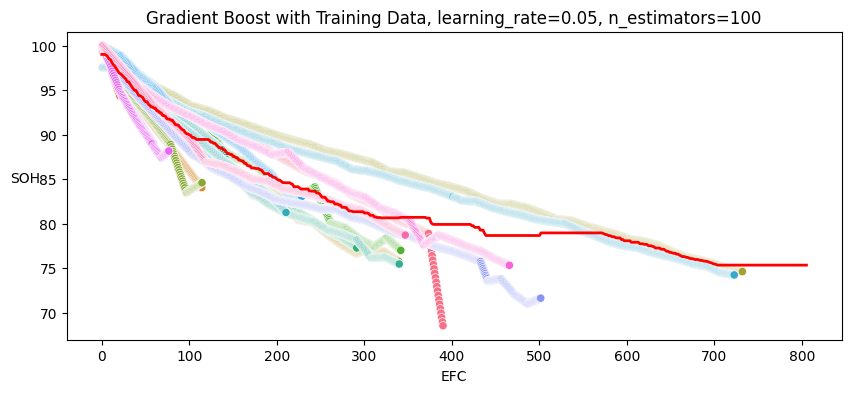

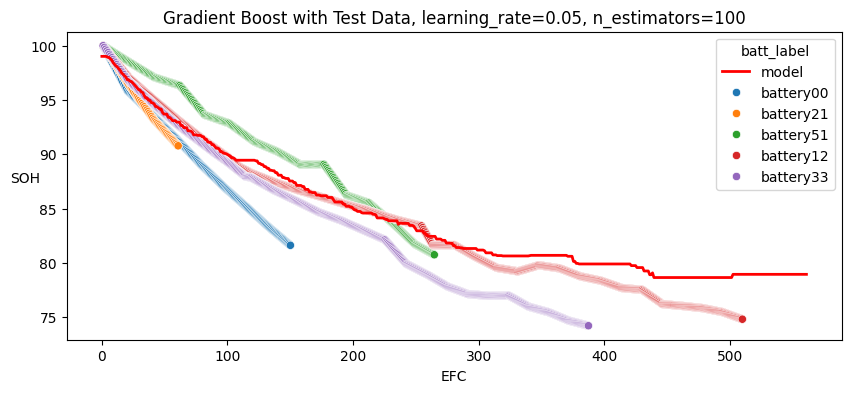

In [6]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['EFC']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'EFC', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'EFC', "SOH", "Gradient Boost with Test Data,", legend=True)

In [7]:
train_features = ['EFC', 'C_rate_cum_avg']
append_mae("EFC and C rate average Features", complete_df, "SOH", train_features)

Feature,Importance
EFC,0.901873
C_rate_cum_avg,0.098127


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
EFC and C rate average Features,2.378254,1.7696,1.556002,1.540345


## Q_norm Features

### Nur Q_norm_at_3.6V Feature

In [8]:
train_features = ['Q_norm_at_3.6_V']
append_mae("Q_norm_at_3.6_V Feature Set", complete_df, "SOH", train_features)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Q_norm_at_3.6_V Feature Set,1.758567,1.218207,1.157408,1.15273


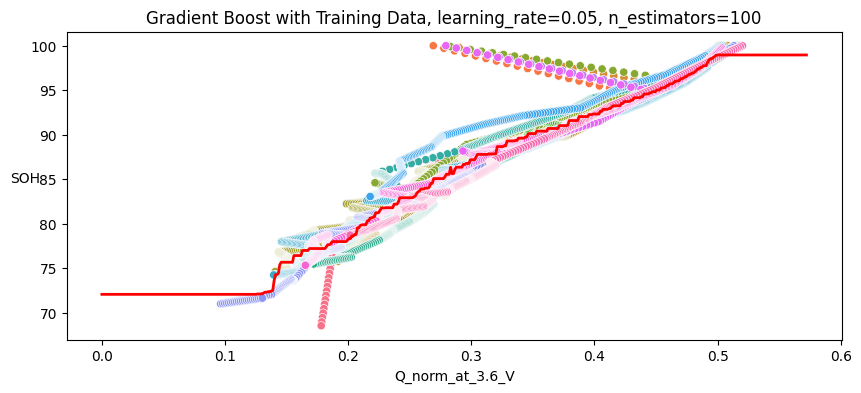

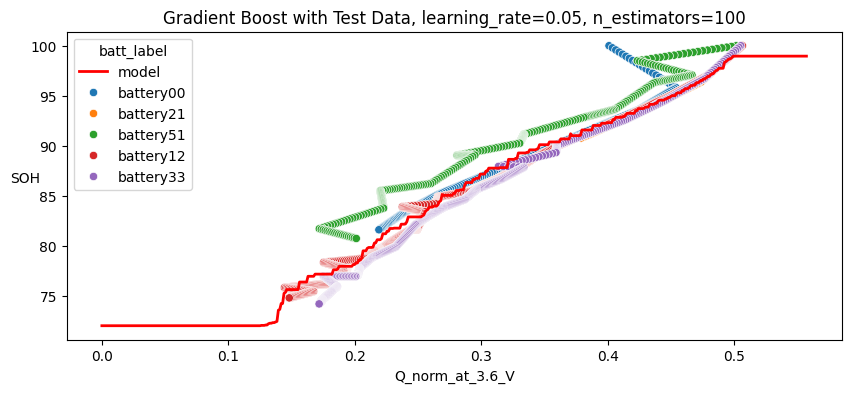

In [9]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['Q_norm_at_3.6_V']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'Q_norm_at_3.6_V', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'Q_norm_at_3.6_V', "SOH", "Gradient Boost with Test Data,", legend=True)

In [10]:
train_features = ['Q_norm_at_3.6_V']
filt_data = complete_df[complete_df['SOH'] < 95]
append_mae("Q_norm_at_3.6_V Feature when SOH < 95 %", filt_data, "SOH", train_features)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Q_norm_at_3.6_V Feature when SOH < 95 %,1.568015,1.133009,1.070864,1.066354


### Feature Set Q_norm

In [11]:
train_features = Q_norm_Features
append_mae("Complete Q_norm Feature Set", complete_df, "SOH", train_features)

Feature,Importance
Q_norm_at_3.6_V,0.917513
Q_norm_at_3.7_V,0.045453
Q_norm_at_3.8_V,0.018693
Q_norm_at_3.9_V,0.018341


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Complete Q_norm Feature Set,1.781691,1.244275,1.129959,1.101715


In [12]:
train_features = Q_norm_Features
filt_data = complete_df[complete_df['SOH'] < 95]
append_mae("Complete Q_norm Feature Set when SOH < 95 %", filt_data, "SOH", train_features)

Feature,Importance
Q_norm_at_3.6_V,0.991861
Q_norm_at_3.9_V,0.003519
Q_norm_at_3.8_V,0.002876
Q_norm_at_3.7_V,0.001744


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Complete Q_norm Feature Set when SOH < 95 %,1.569695,1.134282,1.047511,1.028273


### Feature Set mit Q_norm_at_3.9V, Q_norm_at_3.8V

In [13]:
train_features = ['Q_norm_at_3.8_V', 'Q_norm_at_3.9_V']
append_mae("Q_norm_at(3.8V, 3.9V) Feature Set", complete_df, "SOH", train_features)

Feature,Importance
Q_norm_at_3.8_V,0.954509
Q_norm_at_3.9_V,0.045491


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
"Q_norm_at(3.8V, 3.9V) Feature Set",2.240328,1.799064,1.707408,1.686749


## Komplettes Feature Set ohne Q_norm

In [14]:
drop_features = ['batt_label','isRefCycle','RUL_EFC'] + Q_norm_Features + SOH_Features
all_features = complete_df.columns
train_features = list(set(all_features) - set(drop_features))
append_mae("Complete Feature Set without Q_norm", complete_df, "SOH", train_features)

Feature,Importance
integral_discharge_squared_T,0.438696
integral_low_volt_high_discharge,0.433413
sec_T_30_45,0.040768
integral_discharge_squared,0.015737
integral_high_temp_high_discharge,0.010020
sec_T_over_40,0.008373
sec_at_low_voltage,0.008282
sec_C_rate_6_7,0.005507
T_cum_min,0.005308
sec_at_high_voltage,0.003169


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Complete Feature Set without Q_norm,1.699308,1.124964,1.050889,1.066008


## Integral Features

### Integral low volt high discharge

In [15]:
train_features = ['integral_low_volt_high_discharge']
append_mae("Integral low volt high discharge Feature", complete_df, "SOH", train_features)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Integral low volt high discharge Feature,1.684929,1.095415,1.019424,1.017439


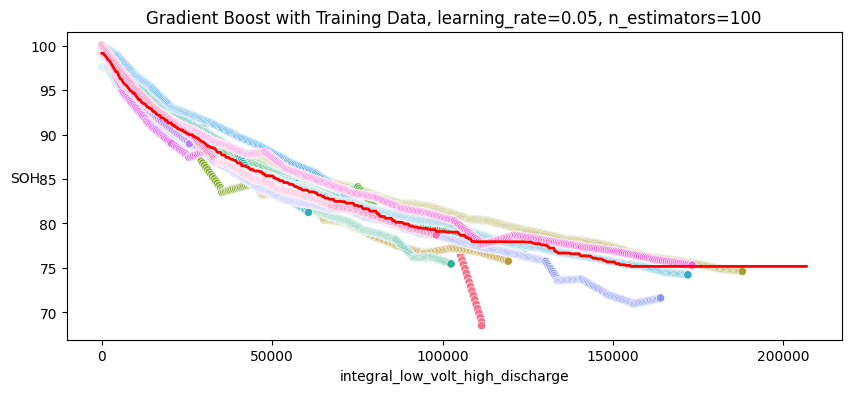

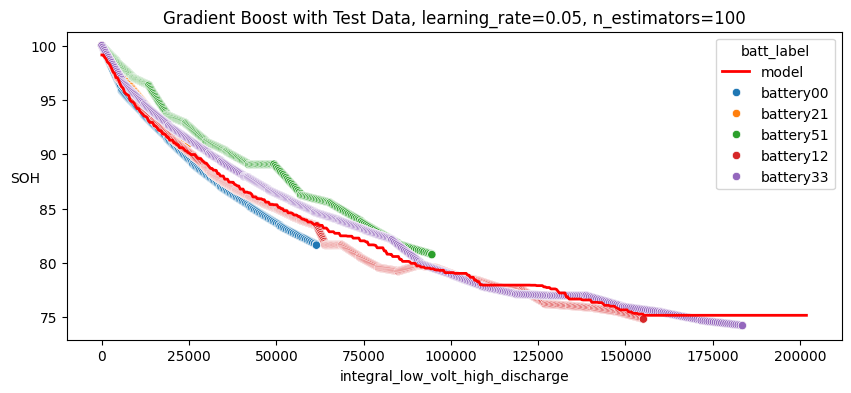

In [16]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_low_volt_high_discharge']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_low_volt_high_discharge', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'integral_low_volt_high_discharge', "SOH", "Gradient Boost with Test Data,", legend=True)

### Integral discharged squared 

In [17]:
train_features = ['integral_discharge_squared']
append_mae("Integral C Rate Squared Feature", complete_df, "SOH", train_features)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Integral C Rate Squared Feature,1.968123,1.468588,1.386631,1.381975


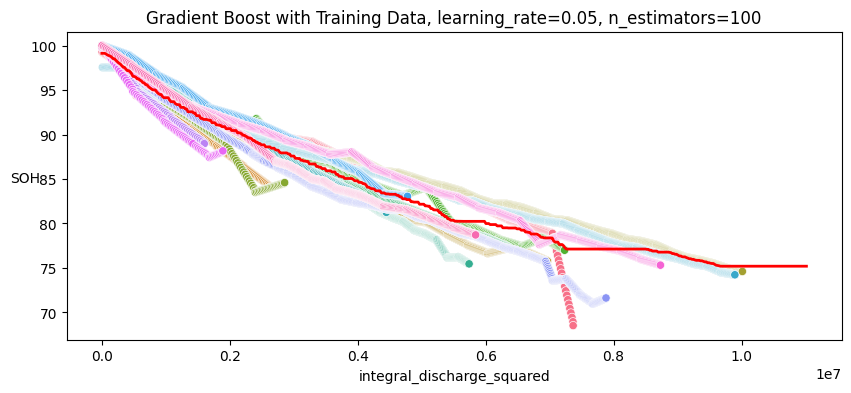

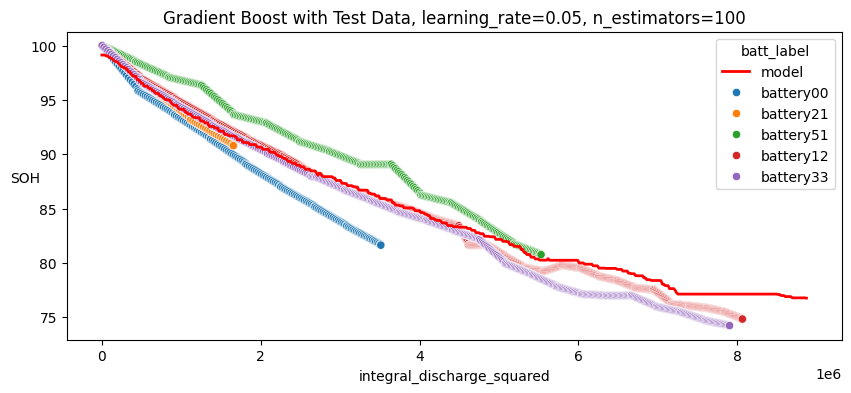

In [18]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_discharge_squared']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_discharge_squared', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'integral_discharge_squared', "SOH", "Gradient Boost with Test Data,", legend=True)

In [19]:
train_features = ['integral_discharge_squared_T']
append_mae("Integral C Rate Squared T Feature", complete_df, "SOH", train_features)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Integral C Rate Squared T Feature,1.7117,1.160663,1.085702,1.081331


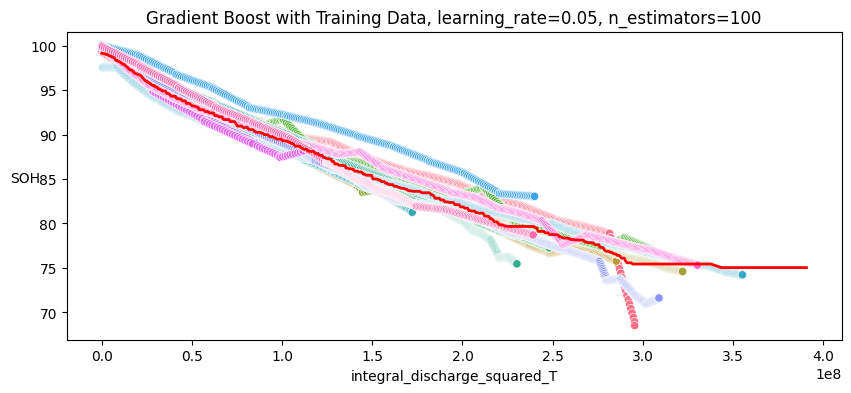

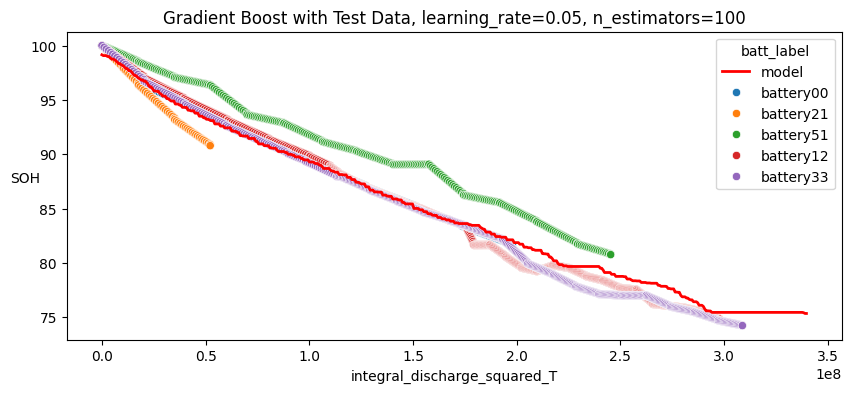

In [20]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_discharge_squared_T']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_discharge_squared_T', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'integral_discharge_squared_T', "SOH", "Gradient Boost with Test Data,", legend=True)

### Feature set with all integrals

In [21]:
train_features = ['integral_low_volt_high_discharge', 'integral_discharge_squared', 'integral_discharge_squared_T','integral_high_temp_high_discharge']
append_mae("All integral features", complete_df, "SOH", train_features)

Feature,Importance
integral_low_volt_high_discharge,0.485046
integral_discharge_squared_T,0.460078
integral_discharge_squared,0.037578
integral_high_temp_high_discharge,0.017298


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
All integral features,1.672963,1.102703,1.019752,1.011836


## Feature-Set R_mOhm and C_rate_cycle_max

In [22]:
train_features = ['R_mOhm','C_rate_cycle_avg']
append_mae("R_mOhm and C_rate_cycle_max Features", complete_df, "SOH", train_features)

Feature,Importance
R_mOhm,0.757999
C_rate_cycle_avg,0.242001


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
R_mOhm and C_rate_cycle_max Features,3.541059,3.117598,2.93204,2.902439


## C Rate Histogram Feature Set

In [23]:
train_features = C_Rate_Hist_Features
append_mae("C Rate Histogram Features", complete_df, "SOH", train_features)

Feature,Importance
sec_C_rate_1_2,0.736103
sec_C_rate_0_0.5,0.128461
sec_C_rate_6_7,0.101330
sec_C_rate_5_6,0.012232
sec_C_rate_3_4,0.008716
sec_C_rate_4_5,0.006560
sec_C_rate_gt_7,0.006547
sec_C_rate_2_3,0.000052
sec_C_rate_0.5_1,0.000000


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
C Rate Histogram Features,2.159027,1.596906,1.322151,1.27635


## T Histogramm Feature Set

In [24]:
train_features = Temp_Hist_Features
append_mae("Temperature Histogram Features", complete_df, "SOH", train_features)

Feature,Importance
sec_T_30_45,0.804298
sec_T_60_80,0.114281
sec_T_45_60,0.049895
sec_T_15_30,0.022448
sec_T_gt_80,0.009077


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Temperature Histogram Features,2.304015,1.842169,1.752989,1.75071


## Feature set t(T > X°C)

In [25]:
temp_threshold_features = ["sec_T_over_30", "sec_T_over_40", "sec_T_over_45", "sec_T_over_50", "sec_T_over_60"]

for feature in temp_threshold_features:
    append_mae(f"{feature} Feature", complete_df, "SOH", [feature])

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
sec_T_over_30 Feature,2.285605,1.882327,1.830577,1.82686


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
sec_T_over_40 Feature,2.213298,1.824399,1.772985,1.76719


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
sec_T_over_45 Feature,2.082607,1.689542,1.679928,1.683022


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
sec_T_over_50 Feature,2.490941,2.146933,2.12884,2.13021


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
sec_T_over_60 Feature,4.32575,4.206809,4.191806,4.194094


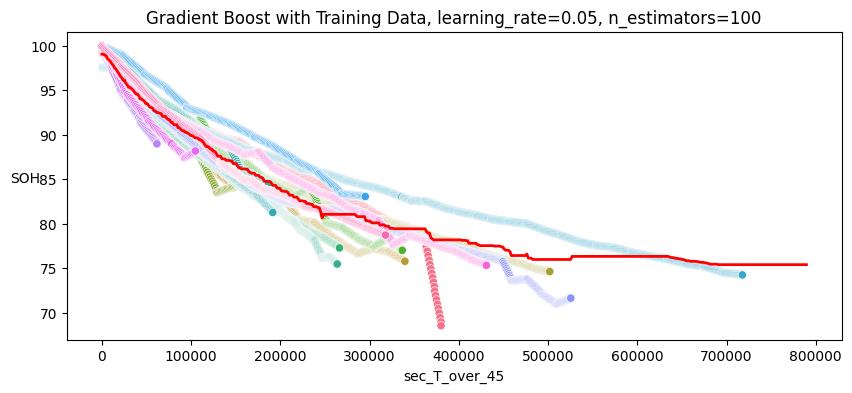

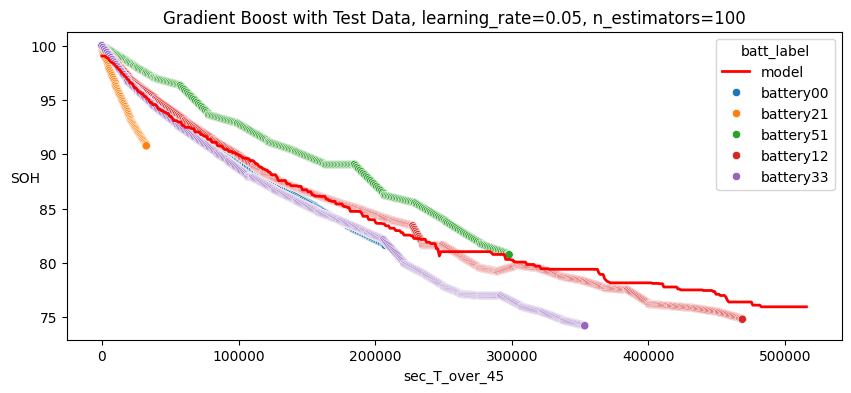

In [26]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['sec_T_over_45']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'sec_T_over_45', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'sec_T_over_45', "SOH", "Gradient Boost with Test Data,", legend=True)

## Power Feature Set ohne Q_norm

In [27]:
corr = complete_df.drop(['batt_label','isRefCycle']+SOH_History_Features, axis=1).corr()
corr = corr['SOH'].abs().sort_values(ascending=False)[:15]
display(pd.DataFrame(corr))

,SOH
SOH,1.000000
integral_discharge_squared_T,0.974334
Q_norm_at_3.6_V,0.966303
Q_norm_at_3.7_V,0.950988
integral_discharge_squared,0.947375
integral_low_volt_high_discharge,0.934437
Q_norm_at_3.8_V,0.910903
integral_high_temp_high_discharge,0.907024
integral_low_volt_high_temp,0.904925
sec_T_over_45,0.897464


In [28]:
corr = complete_df.drop(['batt_label','isRefCycle'], axis=1).corr()
corr = corr['integral_low_volt_high_discharge'].abs().sort_values()[:15]
display(pd.DataFrame(corr))

,integral_low_volt_high_discharge
sec_C_rate_2_3,0.031880
T_cum_avg,0.036175
T_cum_max,0.048384
T_cycle_avg,0.070065
sec_T_gt_80,0.089974
T_cycle_min,0.125021
sec_C_rate_gt_7,0.143687
T_cum_min,0.157202
delta_SOH(-120EFC),0.158154
T_cycle_max,0.164787


In [29]:
power_features = ['integral_low_volt_high_discharge', 'integral_discharge_squared_T',\
                  'T_cum_avg', 'T_cum_max', 'sec_T_gt_80'] + C_Rate_Hist_Features
append_mae("Power Features ohne Q_norm", complete_df, "SOH", power_features)

Feature,Importance
integral_low_volt_high_discharge,0.478479
integral_discharge_squared_T,0.461427
sec_C_rate_1_2,0.025232
sec_C_rate_0_0.5,0.012779
sec_C_rate_6_7,0.008631
T_cum_avg,0.005285
sec_C_rate_5_6,0.003966
T_cum_max,0.002246
sec_C_rate_3_4,0.000961
sec_T_gt_80,0.000794


,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Power Features ohne Q_norm,1.675417,1.026618,0.961127,0.988702


### Zusammenfassung Machine Learning SOH

#### Gradient Boost

In [30]:
all_mae_df = pd.DataFrame(all_mae)
display(all_mae_df)

,MAE @ 10 Est,MAE @ 30 Est,MAE @ 100 Est,MAE @ 300 Est
Complete Feature Set,1.690746,1.152661,1.055190,1.069730
EFC Feature,2.507723,2.083100,2.012505,2.005702
EFC and C rate average Features,2.378254,1.769600,1.556002,1.540345
Q_norm_at_3.6_V Feature Set,1.758567,1.218207,1.157408,1.152730
Q_norm_at_3.6_V Feature when SOH < 95 %,1.568015,1.133009,1.070864,1.066354
Complete Q_norm Feature Set,1.781691,1.244275,1.129959,1.101715
Complete Q_norm Feature Set when SOH < 95 %,1.569695,1.134282,1.047511,1.028273
"Q_norm_at(3.8V, 3.9V) Feature Set",2.240328,1.799064,1.707408,1.686749
Complete Feature Set without Q_norm,1.699308,1.124964,1.050889,1.066008
Integral low volt high discharge Feature,1.684929,1.095415,1.019424,1.017439


## Lineare Regression mit integral_discharge_squared_T Feature

In [31]:
from sklearn.linear_model import LinearRegression

def train_linear_regression(data, target, feature_set):
    '''
    Berechnet lineare Regression
    '''

    y = data[target]
    
    if len(feature_set) == 1:
        X = np.array(data[feature_set[0]]).reshape(-1,1)
    else:
        X = data[feature_set]

    linReg = LinearRegression()
    linReg.fit(X, y)
    y_predict = linReg.predict(X)
    mae = mean_absolute_error(y, y_predict)

    coef = linReg.coef_
    intercept = linReg.intercept_
        
    return mae, coef, intercept, linReg



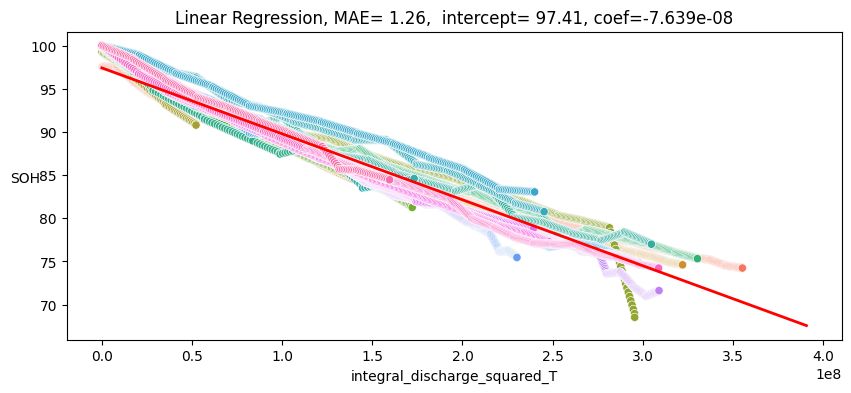

In [32]:
mae, coef, intercept, model = train_linear_regression(complete_df, "SOH", ["integral_discharge_squared_T"])
plot_predictions(model, complete_df, 'integral_discharge_squared_T', "SOH", f"Linear Regression, MAE={mae: .2f}, ", gradientBoost=False)

## Scatter Plot mit Power Feature Set

In [33]:
power_gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=100, learning_rate=0.05, random_state=42)

X_train = train_df[power_features]
y_train = train_df['SOH']
X_test = test_df[power_features]
y_test = test_df['SOH']

power_gbrt.fit(X_train, y_train)
y_test_predict = power_gbrt.predict(X_test)
y_test = test_df['SOH']
test_mae = mean_absolute_error(y_test,y_test_predict)
test_mae

0.9249900012438231

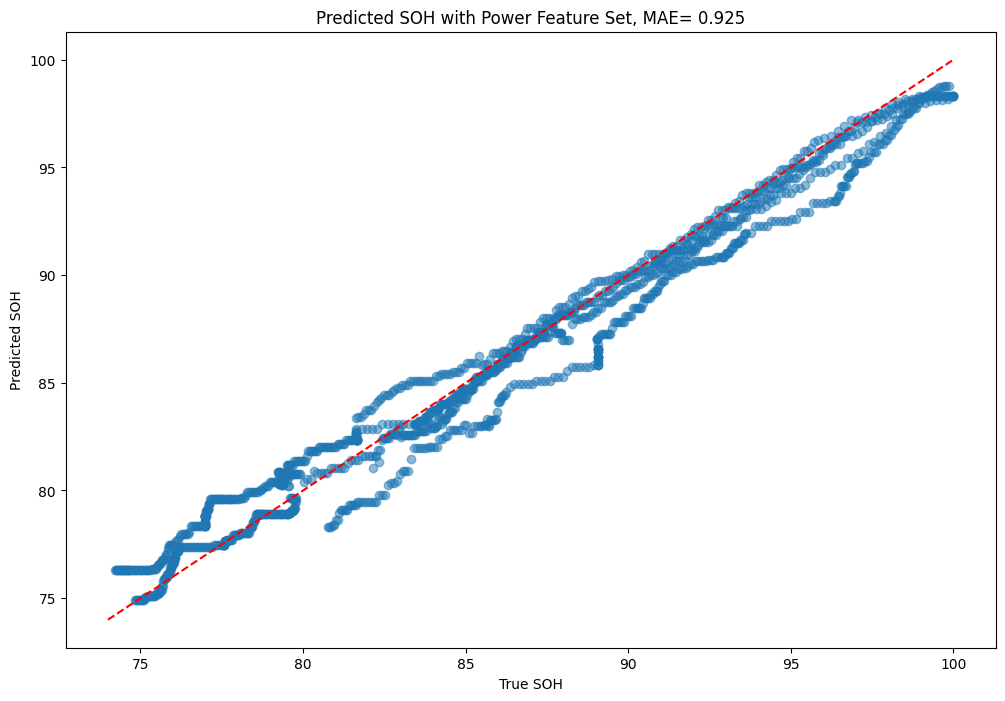

In [34]:
import numpy as np

plt.figure(figsize=(12,8))
plt.title(f"Predicted SOH with Power Feature Set, MAE={test_mae: .3f}")
plt.scatter(y_test, y_test_predict, alpha=0.5)
plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.plot(np.linspace(74,100), np.linspace(74,100), 'r--')
plt.show()

# Zusammenfassung Machine Learning SOH

* **Q_norm_at_3.6_V, integral_low_volt_high_discharge und integral_discharge_squared_T die wichtigsten einzelnen Features:**
    * **Q_norm_at_3.6_V**: Ladung die benötigt wird um Zelle von Vollladung (ca. 4,2V) auf Nennspannung (3,6V) zu entladen,
              normiert auf die nominale Kapazität. Im realen Betrieb nicht immer vorhanden. Als einzelnes Feature konnte mit Gradient
              Boost ein MAE von ca. 1,3 % erzielt werden. Mit allen Q(V) bis 3,6V 1,1 %. Bei SOH Werten über 95 % kommt es bei einzelnen
              Batterien zu großen Abweichungen zur Modellvorhersage mittels Q(V), für SOH Werte kleiner 95 % sind keine großen Abweichungen
              mehr zu beobachten. 
    * **integral_low_volt_high_discharge**: sum(max(3,1V-voltage, 0) * max(C_rate - 1C, 0) * delta_t). Gewichtetes Integral
      wenn Zellspannung unter 3,1V und Entladestrom über 1C. In realen Betrieb als einziges ML Feature ungeeignet, da
      Batteriemanagementsystem (BMS) Entladestrom begrenzt wenn Batterieladung gering. Je nach BMS Strategie kann es als ergänzendes
      Feature sinnvoll sein. Als einzelnes Feature konnte mit Gradient Boost ein MAE von ca. 1,0 % erzielt werden.
    * **integral_discharge_squared_T**: sum(I ** 2 * (10 + abs(T-20°C)) * delta_t). MAE 1,1 % wenn einziges ML Feature. Kann in der
      Praxis nützlich sein, da es auch im Betrieb mit einer BMS aufintegriert wird, gewichtet Über- und Untertemperaturen. Verläuft
      gut linear zum SOH, daher wird auch mit linearer Regression noch ein MAE von 1,3 % erreicht. Vorhersage-Algorithmus von linearer
      Regression kann auch leicht auf BMS Mikrocontroller implementiert werden.
* **komplettes C Rate Histogramm ebenfalls gutes Feature:**
    * Mit kompletten C Rate Histogramm konnte mit Gradient Boost ein MAE von ca. 1,3 % erzielt werden.
* **Bei meisten Features sind 100 Estimators (bei max_depth = 2) beste Modellkomplexität bei Gradient Boost**
* **Bei reinen Temperaturfeatures sec_T_over_45 sinnvolles Feature**
    * **sec_T_over_45**: Sekunden bei der die Batterie eine Temperatur über 45 °C hat. Im vergleich zu Thresholds von 40 °C und 50 °C
      konnte hier der beste MAE erzielt werden (ca. 1,7 %).
    * Als Feature für den EU Battery Pass sinnvoll, da hier eine Angabe in Sekunden gefordert ist, bei der die Batterie in einem
      kritischen Zustand ist
    * Komplettes Temperatur Histogramm nicht sinnvoll, da hier keine höherer MAE als mit den einzelnen Feature sec_T_over_45 erzielt
      werden konnte
* **Mit kombinierten Features konnte der beste MAE von ca. 1,0 % erzielt werden.**
* **Bei realen Anwendungen kann eine Kombination aus mehreren Features je nach Anwendungsfall sinnvoll sein**
    * integral_discharge_squared_T Feature deckt gut normalen Betrieb ab
    * Je nach BMS-Strategie können ergänzende Features wie integral_low_volt_high_discharge oder integral_high_temp_high_discharge
      hinzugefügt werden
    * Bei hoher Bandbreite von der C Rate kann ein C Rate Histogramm sinnvoll sein
    * Bei stark schwankender Umgebungstemperatur kann T_avg und T_max oder Sekunden über Temperatur X als zusätzliche Features sinnvoll sein
    * Bei größeren Teilentladungen können Q(V) Features zur SOH-Vorhersage verwendet werden
* **Als einzelnes universelles Feature kann sec_T_over_45 oder integral_discharge_squared_T sinnvoll sein**
    * **sec_T_over_45**: Sekunden bei der Temperatur über 45 °C, wird in der Praxis oft beim EU Battery Pass verwendet, MAE ca. 1,7 %
    * **integral_discharge_squared_T**: sum(I ** 2 * (10 + abs(T-20°C)) * delta_t), MAE ca. 1,1 % mit Gradient Boost, da das Feature gut linear
      zum SOH verläuft, kann auch mit linearer Regression ein guter MAE von ca. 1,3 % erreicht werden!